# Reverse Process Test

In [ ]:
import sys, importlib, os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision.utils
from pathlib import Path


# Parameters to set

In [ ]:
# Set the following parameters
sde_type = "subVP"
num_steps = 1000
batch_size = 1
VAE_SCALE_FACTOR = 0.18215
guidance_scale = 1.5
num_attributes = 40
conditional = True
cfg_mask_prob = 0.1


cfg = {
    "sde_type": sde_type,
    "N": num_steps, 
    "vae_scale_factor" : VAE_SCALE_FACTOR,
    "guidance_scale": guidance_scale,
    "num_attributes": num_attributes,
    "conditional": conditional,
    "cfg_mask_prob": cfg_mask_prob
}

In [4]:
# Importing project packages
cwd = Path(os.getcwd())
root_dir = cwd.parent

utils_dir = root_dir.joinpath('src','utils')
weights_dir = root_dir.joinpath('checkpoints','weights')
model_dir = root_dir.joinpath('src','model')
yaml_file_path = root_dir.joinpath('experiments','base_config.yaml')


# Making packages importable
sys.path.append(str(root_dir))

In [ ]:
weights_name = 'LDM_final_T1000_LR00001_E100_SA_RESUME_ts20251221_111012.pth' 

In [6]:
from src.utils import WIP_SDE, WIP_processes
from src.models import components
from src.models import UNet


importlib.reload(WIP_SDE)
importlib.reload(WIP_processes)
importlib.reload(components)
importlib.reload(UNet)

# UNet = unet_model.UNet
# Unet = unet_base.Unet
UNet = UNet.UNet
from src.utils.WIP_SDE import VESDE, SubVPSDE
from src.utils.WIP_processes import Diffusion_Processes
from src.models.components import SinusoidalPositionEmbeddings # Required by unet_model
#from src.models.unet_model import UNet


In [7]:
diffusion = Diffusion_Processes(cfg)
diffusion.sde_type

'subvp'

In [8]:
from diffusers import UNet2DModel
model_id = "google/ncsnpp-celebahq-256"
model = UNet2DModel.from_pretrained(model_id)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model.to(device)
model.eval()


KeyboardInterrupt: 

# Weights to test (Our Model)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Instantiate the REAL Unet model from unet_model.py
print("Instantiating UNet model...")
model = UNet(in_channels=4, out_channels=4).to(device)
model

Using device: cuda
Instantiating UNet model...


UNet(
  (time_mlp): Sequential(
    (0): SinusoidalPositionEmbeddings()
    (1): Linear(in_features=32, out_features=128, bias=True)
    (2): SiLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
  )
  (input_conv): Conv2d(4, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (down_blocks): ModuleList(
    (0-1): 2 x ResBlock(
      (norm1): GroupNorm(8, 32, eps=1e-05, affine=True)
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (time_proj): Sequential(
        (0): SiLU()
        (1): Linear(in_features=128, out_features=64, bias=True)
      )
      (norm2): GroupNorm(8, 32, eps=1e-05, affine=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (act): SiLU()
      (dropout): Dropout(p=0.0, inplace=False)
      (shortcut): Identity()
    )
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ResBlock(
      (norm1): GroupNorm(8, 32, eps=1e-05, affine=True)


In [22]:
def _extract_state_dict(ckpt):
    for k in ("state_dict", "model",  "model_state_dict"): #, "ema"):
        if isinstance(ckpt, dict) and k in ckpt and isinstance(ckpt[k], dict):
            return ckpt[k]
    return ckpt

def _remove_ema(sd: dict) -> dict:
    return {
        k: v for k, v in sd.items()
        if not (
            k.startswith("ema.") or
            k.startswith("ema_model.") or
            k.startswith("model_ema.")
        )
    }


def _strip_prefixes(sd: dict) -> dict:
    if any(k.startswith("module.") for k in sd):
        sd = {k.split("module.", 1)[1] if k.startswith("module.") else k: v for k, v in sd.items()}
    # if all(k.startswith("unet.") for k in sd):
    sd = {k.replace("unet.", "", 1) if k.startswith("unet.") else k: v for k, v in sd.items()}
    return sd

def load_model_from_local(model: nn.Module, ckpt_path: str, device: torch.device) -> bool:
    """Load checkpoint from local filesystem instead of Google Drive."""
    if not os.path.isfile(ckpt_path):
        print(f"Error: Checkpoint not found at {ckpt_path}")
        return False
    print(f"Loading model weights from {ckpt_path} ...")

    try:
        ckpt = torch.load(ckpt_path, map_location="cpu")
    except Exception as e:
        print(f"[torch.load] failed: {e}")
        return False

    sd = _extract_state_dict(ckpt)
    sd = _strip_prefixes(sd)
    sd = _remove_ema(sd)



    num_tensors = len(sd)
    num_params = sum(v.numel() for v in sd.values() if torch.is_tensor(v))
    print(f"Checkpoint state_dict: {num_tensors} tensors, {num_params:,} total parameters")

    model_keys = set(model.state_dict().keys())
    filtered = {k: v for k, v in sd.items() if k in model_keys}

    dropped = sorted(k for k in sd.keys() if k not in model_keys)
    if dropped:
        print(f"Dropping {len(dropped)} unexpected keys (showing up to 8):")
        for k in dropped[:]:
            print("  ", k)
        if len(dropped) > 8:
            print("  ...")

    res = model.load_state_dict(filtered, strict=False)
    print(f"Loaded. missing={len(res.missing_keys)} unexpected={len(res.unexpected_keys)}")

    model.to(device).eval()
    return True

In [23]:
# --- 3. Load Weights ---
num_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {num_params:,}")
ckpt_path = weights_dir.joinpath(weights_name)
load_model_from_local(model, ckpt_path, device)
ckpt_path

Model parameters: 4,640,484
Loading model weights from c:\Users\marco\Desktop\Magistrale\ERASMUS\COURSES TUM\Practicals\Hands on Generative AI\Project\Hands-on-Generative-AI\checkpoints\weights\LDM_final_T1000_LR00001_E100_SA_RESUME_ts20251221_111012.pth ...
Checkpoint state_dict: 319 tensors, 4,640,484 total parameters
Loaded. missing=0 unexpected=0


WindowsPath('c:/Users/marco/Desktop/Magistrale/ERASMUS/COURSES TUM/Practicals/Hands on Generative AI/Project/Hands-on-Generative-AI/checkpoints/weights/LDM_final_T1000_LR00001_E100_SA_RESUME_ts20251221_111012.pth')

In [ ]:
# 2. Define the Wrapper (Fixes the TypeError)
def model_fn(x, t, labels):
    # Diffusers expects t to be shape (B,) or a scalar, usually handles it fine.
    with torch.no_grad():
        out = model(x, t, labels)
            
    # Extract the actual tensor from the output object
    if hasattr(out, 'sample'):
        return out.sample
    return out[0]


In [25]:
from diffusers import AutoencoderKL
vae = AutoencoderKL.from_pretrained("stabilityai/sd-vae-ft-mse").to(next(model.parameters()).device).eval()
VAE_SCALE_FACTOR = cfg['vae_scale_factor']
VAE_SCALE_FACTOR

0.18215

In [26]:
def decode_from_latent(latents: torch.Tensor):
    """Converte latenti in pixel [0, 1]."""
    latents = latents / VAE_SCALE_FACTOR
    with torch.no_grad():
        image = vae.decode(latents).sample
    return (image / 2 + 0.5).clamp(0, 1)

This is our SDE: <src.utils.WIP_SDE.SubVPSDE object at 0x000001F7F7BFAAD0>
This is the value of T: 1.0
Check prior subvp: Mean = -0.0003547647502273321, Std = 0.9937788248062134
[reverse step 901/1000 | i=900 | t=0.9000]
mean=-0.0299, std=1.0110, min=-3.5241, max=3.4813
Time of last 100 steps: 1.8621954917907715. Time remaining 18.621954917907715.



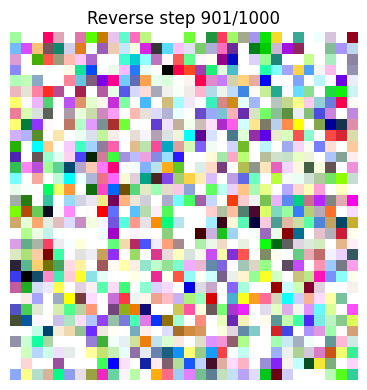

[reverse step 801/1000 | i=800 | t=0.8000]
mean=-0.0211, std=1.0130, min=-3.5864, max=4.0544
Time of last 100 steps: 1.5198166370391846. Time remaining 30.39633274078369.



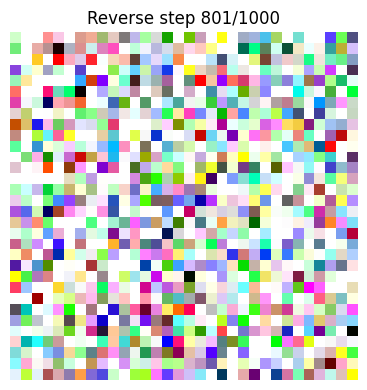

[reverse step 701/1000 | i=700 | t=0.7000]
mean=-0.0098, std=1.0051, min=-3.6430, max=4.0885
Time of last 100 steps: 1.4302456378936768. Time remaining 42.9073691368103.



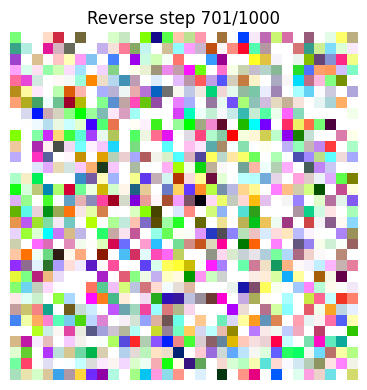

[reverse step 601/1000 | i=600 | t=0.6000]
mean=0.0120, std=0.9851, min=-3.0278, max=3.5795
Time of last 100 steps: 1.4403016567230225. Time remaining 57.6120662689209.



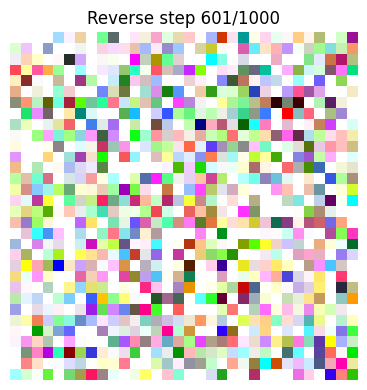

[reverse step 501/1000 | i=500 | t=0.5000]
mean=0.0542, std=0.9636, min=-3.3818, max=3.6702
Time of last 100 steps: 1.4254956245422363. Time remaining 71.27478122711182.



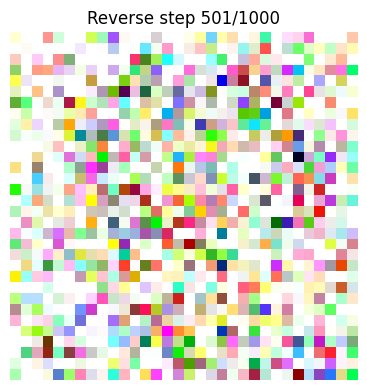

[reverse step 401/1000 | i=400 | t=0.4000]
mean=0.1034, std=0.9544, min=-3.0415, max=3.8601
Time of last 100 steps: 1.4183003902435303. Time remaining 85.09802341461182.



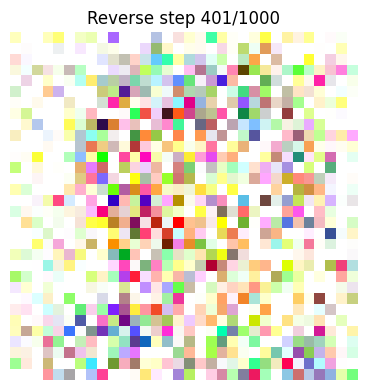

[reverse step 301/1000 | i=300 | t=0.3000]
mean=0.1686, std=0.9889, min=-2.9766, max=3.6706
Time of last 100 steps: 1.43845796585083. Time remaining 100.6920576095581.



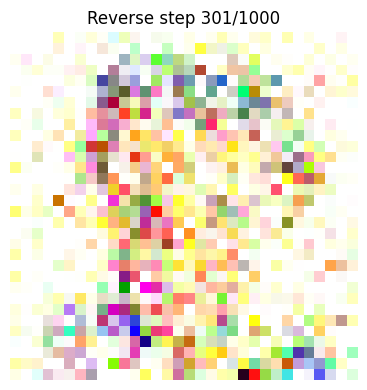

[reverse step 201/1000 | i=200 | t=0.2000]
mean=0.2132, std=1.0648, min=-2.8285, max=3.9599
Time of last 100 steps: 1.6145861148834229. Time remaining 129.16688919067383.



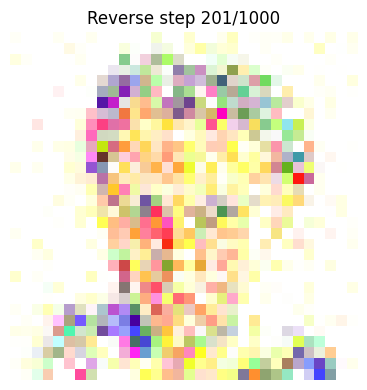

[reverse step 101/1000 | i=100 | t=0.1000]
mean=0.2452, std=1.1819, min=-2.9277, max=3.9019
Time of last 100 steps: 1.7972700595855713. Time remaining 161.75430536270142.



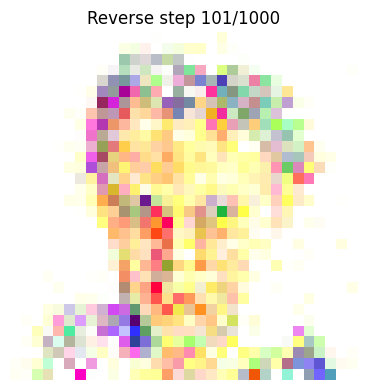

[reverse step 15/1000 | i=14 | t=0.0140]
mean=0.2574, std=1.2379, min=-2.9757, max=4.0593
Time of last 100 steps: 1.2311599254608154. Time remaining 121.88483262062073.



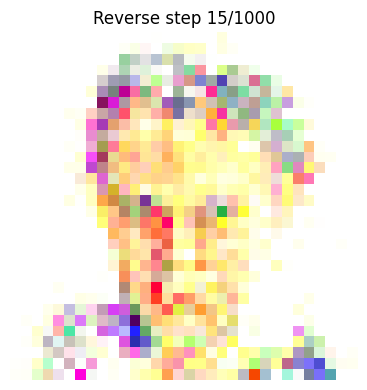

[reverse step 14/1000 | i=13 | t=0.0130]
mean=0.2574, std=1.2381, min=-2.9755, max=4.0578
Time of last 100 steps: 0.03135800361633301. Time remaining 3.1044423580169678.



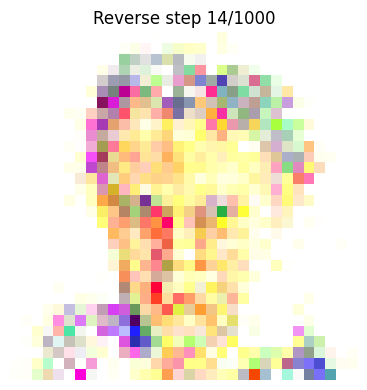

[reverse step 13/1000 | i=12 | t=0.0120]
mean=0.2575, std=1.2383, min=-2.9779, max=4.0563
Time of last 100 steps: 0.05287623405456543. Time remaining 5.2347471714019775.



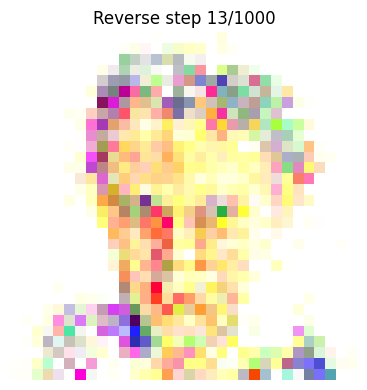

[reverse step 12/1000 | i=11 | t=0.0110]
mean=0.2575, std=1.2385, min=-2.9765, max=4.0566
Time of last 100 steps: 0.05404043197631836. Time remaining 5.350002765655518.



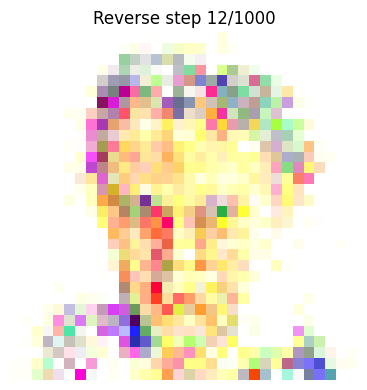

[reverse step 11/1000 | i=10 | t=0.0100]
mean=0.2575, std=1.2387, min=-2.9758, max=4.0561
Time of last 100 steps: 0.04595017433166504. Time remaining 4.549067258834839.



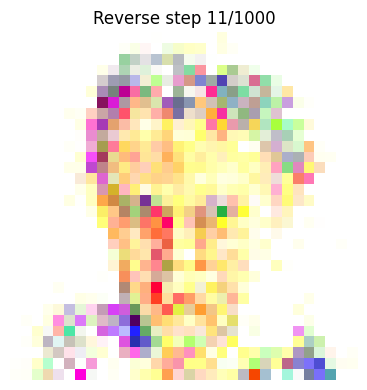

[reverse step 10/1000 | i=9 | t=0.0090]
mean=0.2576, std=1.2388, min=-2.9748, max=4.0575
Time of last 100 steps: 0.05121135711669922. Time remaining 5.121135711669922.



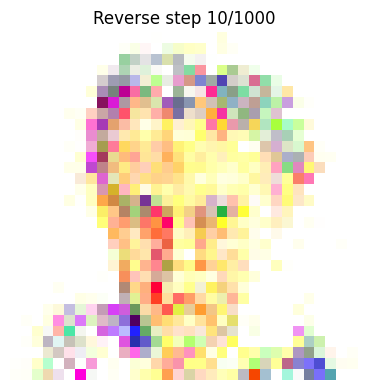

[reverse step 9/1000 | i=8 | t=0.0080]
mean=0.2576, std=1.2390, min=-2.9744, max=4.0574
Time of last 100 steps: 0.05323052406311035. Time remaining 5.323052406311035.



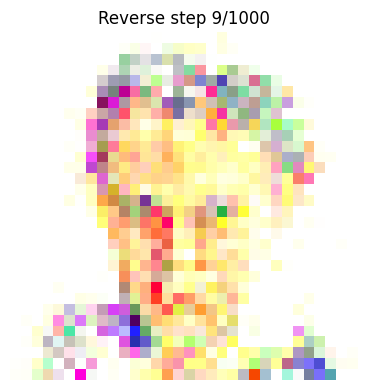

[reverse step 8/1000 | i=7 | t=0.0070]
mean=0.2576, std=1.2391, min=-2.9740, max=4.0584
Time of last 100 steps: 0.04846549034118652. Time remaining 4.846549034118652.



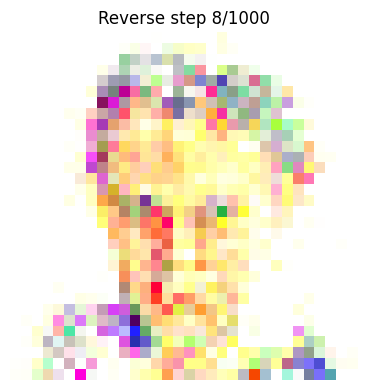

[reverse step 7/1000 | i=6 | t=0.0060]
mean=0.2576, std=1.2393, min=-2.9746, max=4.0586
Time of last 100 steps: 0.3115880489349365. Time remaining 31.158804893493652.



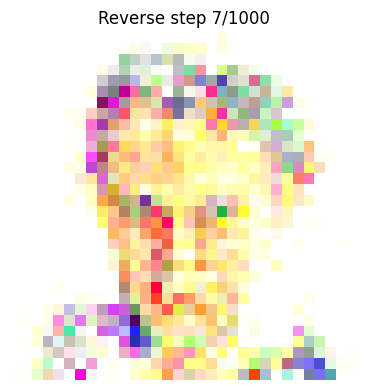

[reverse step 6/1000 | i=5 | t=0.0050]
mean=0.2577, std=1.2394, min=-2.9746, max=4.0594
Time of last 100 steps: 0.05498838424682617. Time remaining 5.498838424682617.



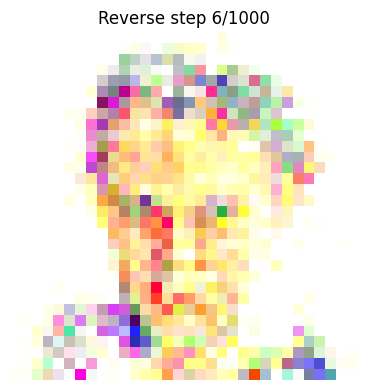

[reverse step 5/1000 | i=4 | t=0.0040]
mean=0.2577, std=1.2395, min=-2.9751, max=4.0600
Time of last 100 steps: 0.05044674873352051. Time remaining 5.044674873352051.



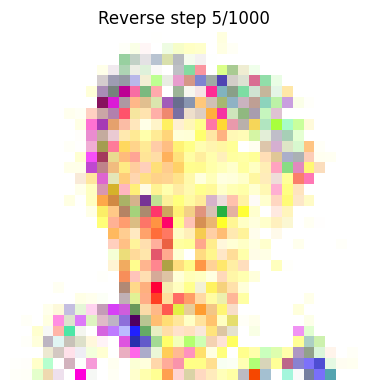

[reverse step 4/1000 | i=3 | t=0.0030]
mean=0.2577, std=1.2396, min=-2.9760, max=4.0615
Time of last 100 steps: 0.04857611656188965. Time remaining 4.857611656188965.



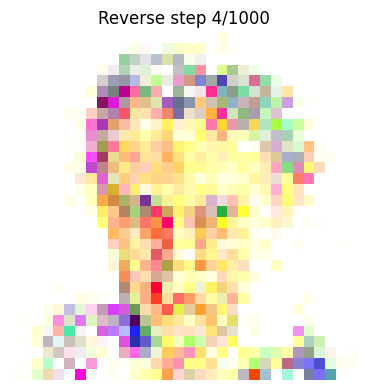

[reverse step 3/1000 | i=2 | t=0.0020]
mean=0.2577, std=1.2397, min=-2.9759, max=4.0617
Time of last 100 steps: 0.034905433654785156. Time remaining 3.4905433654785156.



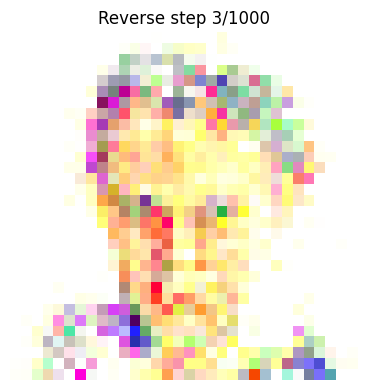

[reverse step 2/1000 | i=1 | t=0.0010]
mean=0.2577, std=1.2398, min=-2.9763, max=4.0619
Time of last 100 steps: 0.05527663230895996. Time remaining 5.527663230895996.



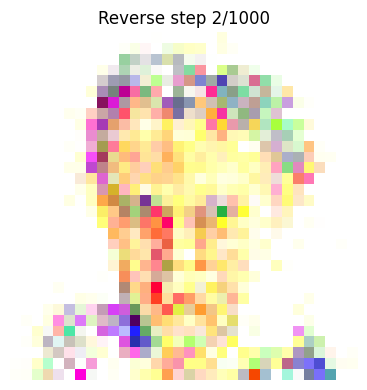

[reverse step 1/1000 | i=0 | t=0.0000]
mean=0.2577, std=1.2398, min=-2.9764, max=4.0621
Time of last 100 steps: 0.04541516304016113. Time remaining 4.541516304016113.



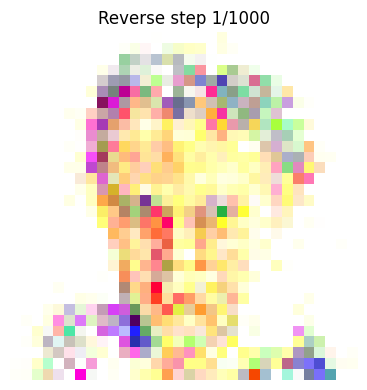

In [27]:
# 3. Run Sampling (Fixes the AttributeError via the class update)
batch_size = 1
samples = diffusion.reverse_process(
    model=model_fn,             
    shape=(batch_size, 4, 32, 32),
    num_steps=cfg.get('N', 1000),
    probability_flow=False,
    device=device                # Pass device explicitly
)

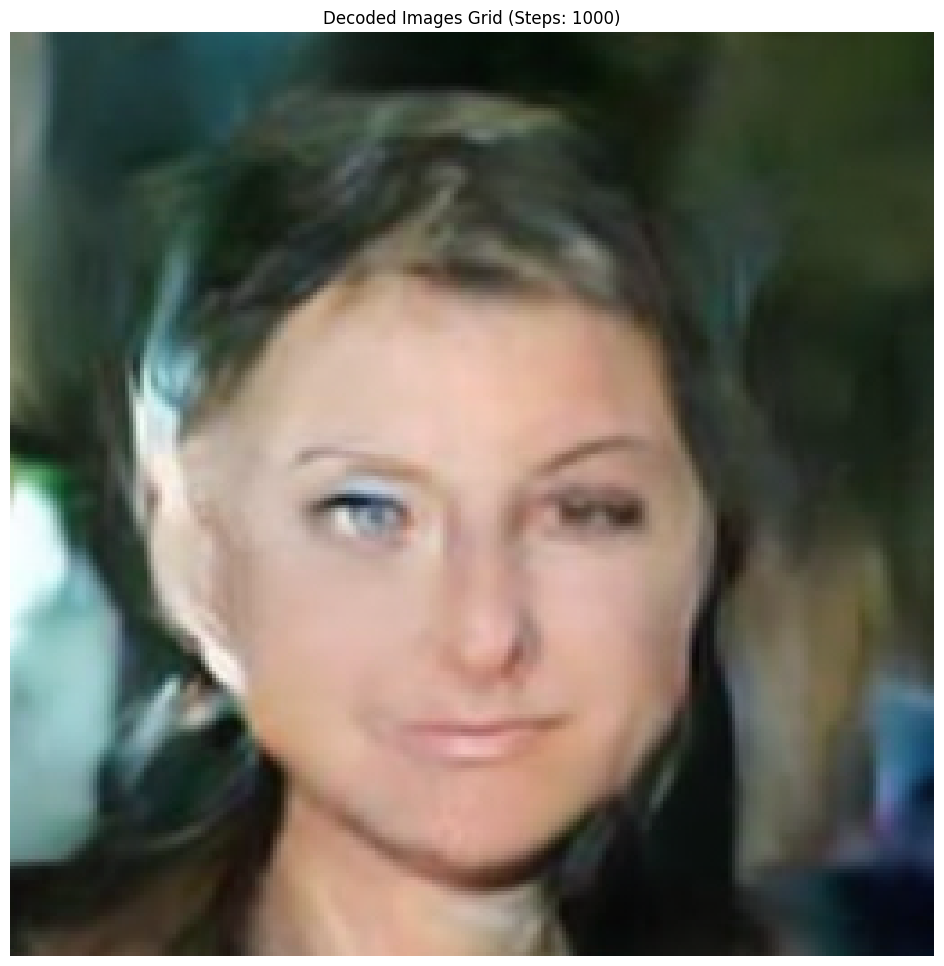

In [36]:
decoded_images = []

# --- 1. Decodifica tutte le immagini e salva in una lista ---
for latent in samples:
    latent = latent.to(next(vae.parameters()).device, dtype=torch.float32).unsqueeze(0)
    decoded = decode_from_latent(latent)  # [1, C, H, W]
    decoded_images.append(decoded[0])      # Rimuovi dimensione batch

# --- 2. Crea un batch da lista di tensori ---
decoded_batch = torch.stack(decoded_images)  # [B, C, H, W]
# --- 3. Crea griglia ---
grid = torchvision.utils.make_grid(decoded_batch, nrow=4, normalize=True, value_range=(0, 1))

# --- 4. Visualizza e salva ---
plt.figure(figsize=(12, 12))
plt.imshow(grid.permute(1, 2, 0).cpu())  # [H, W, C]
plt.axis("off")
plt.title(f"Decoded Images Grid (Steps: {cfg['N']})")

# Salva la griglia
plt.show()


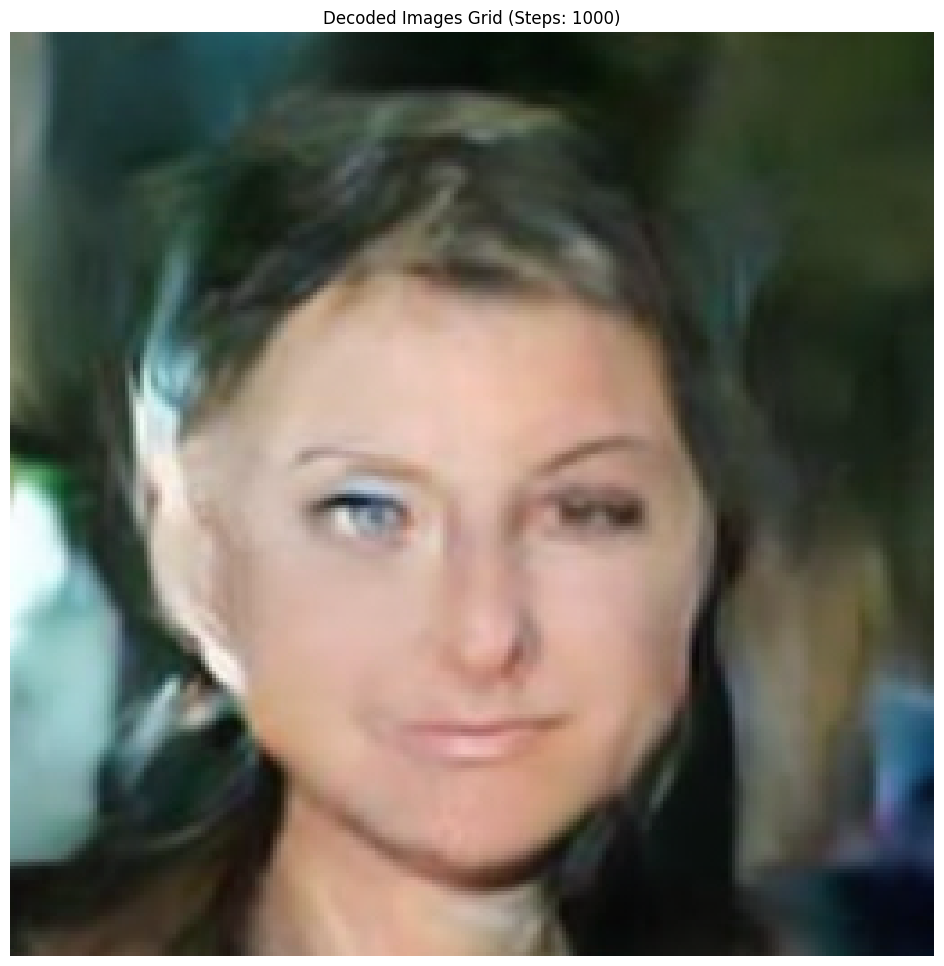

Saved Grid in: images/decoded_grid_steps_1000_LDM_final_T1000_LR00001_E500_SA_ts20251221_084546.pth.png


In [37]:
import os

decoded_images = []

# --- 1. Decodifica tutte le immagini e salva in una lista ---
for latent in samples:
    latent = latent.to(next(vae.parameters()).device, dtype=torch.float32).unsqueeze(0)
    decoded = decode_from_latent(latent)  # [1, C, H, W]
    decoded_images.append(decoded[0])     # Rimuovi dimensione batch

# --- 2. Crea un batch da lista di tensori ---
decoded_batch = torch.stack(decoded_images)  # [B, C, H, W]

# --- 3. Crea griglia ---
grid = torchvision.utils.make_grid(
    decoded_batch,
    nrow=4,
    normalize=True,
    value_range=(0, 1)
)

# --- 4. Visualizza e salva ---
os.makedirs("images", exist_ok=True)

plt.figure(figsize=(12, 12))
plt.imshow(grid.permute(1, 2, 0).cpu())  # [H, W, C]
plt.axis("off")
plt.title(f"Decoded Images Grid (Steps: {cfg['N']})")

# Salva la griglia
save_path = f"images/decoded_grid_steps_{cfg['N']}_{weights_name}.png"
plt.savefig(save_path, bbox_inches="tight", pad_inches=0)
plt.show()

print(f"Saved Grid in: {save_path}")
